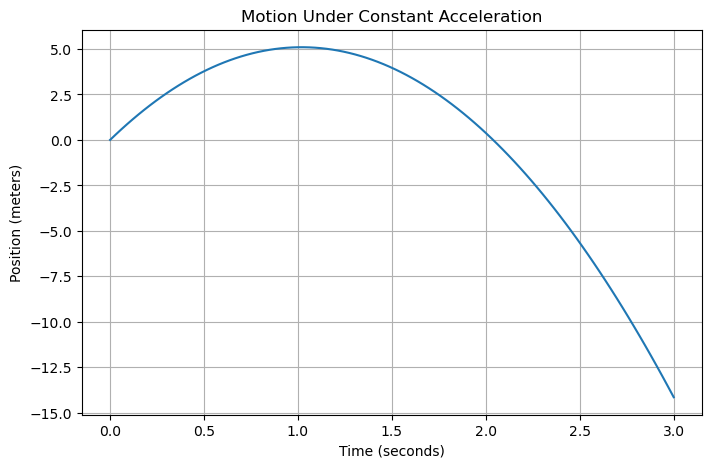

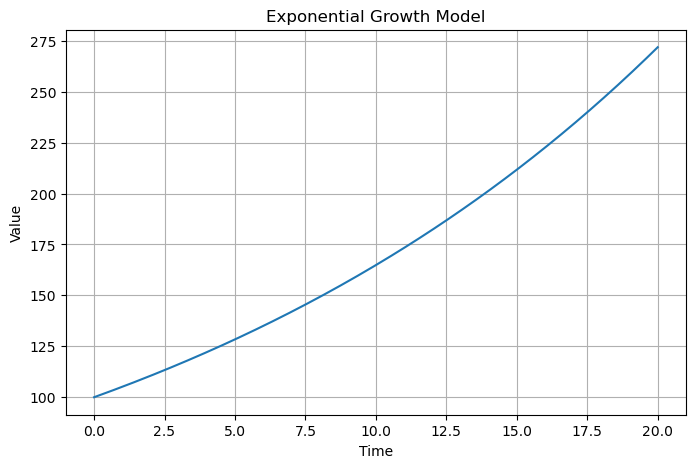

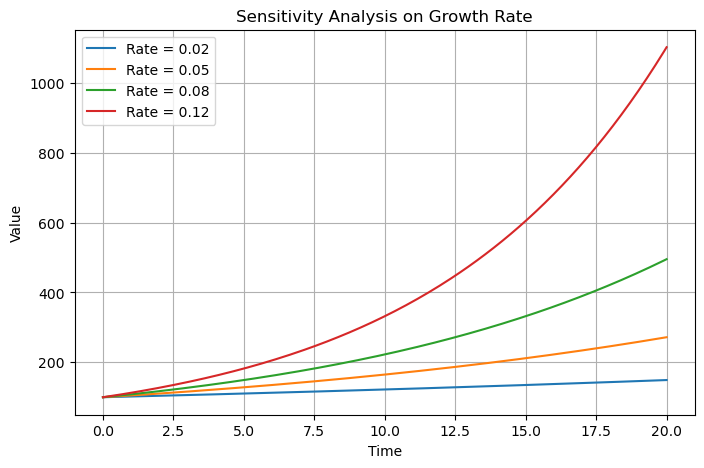

PHYSICAL MODEL VALIDATION:
         Time (s)  Position (m)
count  100.000000    100.000000
mean     1.500000      0.210682
std      0.879136      5.344240
min      0.000000    -14.145000
25%      0.750000     -2.332407
50%      1.500000      2.281171
75%      2.250000      4.385148
max      3.000000      5.096253

MATHEMATICAL MODEL VALIDATION:
             Time       Value
count  200.000000  200.000000
mean    10.000000  171.898972
std      5.817003   49.584114
min      0.000000  100.000000
25%      5.000000  128.402845
50%     10.000000  164.872647
75%     15.000000  211.700503
max     20.000000  271.828183


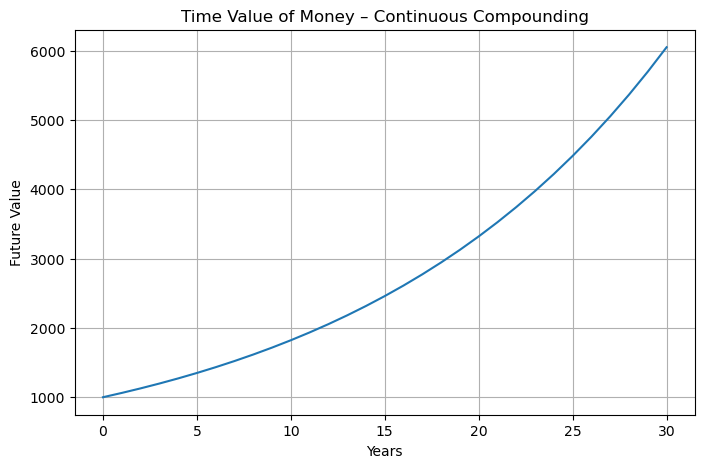

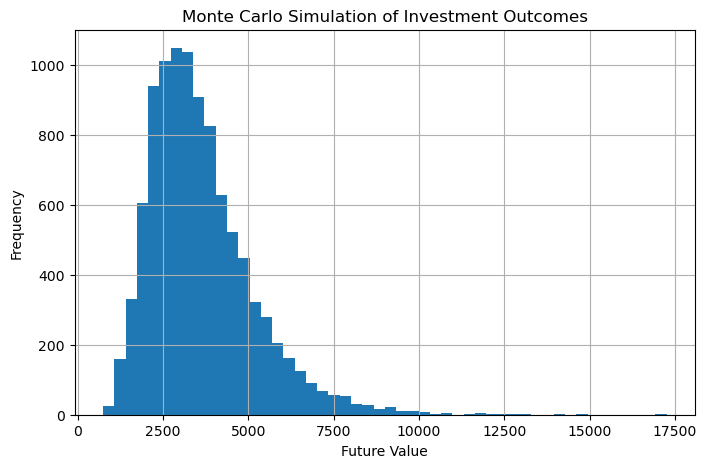

Monte Carlo Results:
Mean FV: 3619.20
5th Percentile: 1725.80
95th Percentile: 6452.01

MODEL EXECUTION COMPLETE
All simulations, validations, and analyses ran successfully.


In [1]:
# ============================================
# PYTHON-BASED ANALYTICAL MODELS
# Simulation and Analysis of Physical and Mathematical Systems
# Author: Kgomotso Mangena
# ============================================

# ---------- 1. IMPORT LIBRARIES ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------- 2. GLOBAL SETTINGS ----------
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)


# ---------- 3. PHYSICAL SYSTEM MODEL ----------
# Motion under constant acceleration
# x(t) = ut + 0.5at^2

def simulate_motion(u, a, t_max, steps):
    t = np.linspace(0, t_max, steps)
    x = u * t + 0.5 * a * t**2

    df = pd.DataFrame({
        "Time (s)": t,
        "Position (m)": x
    })
    return df


# Parameters
u = 10.0       # initial velocity (m/s)
a = -9.81      # acceleration due to gravity (m/s^2)

motion_df = simulate_motion(u, a, t_max=3, steps=100)

# ---------- 4. VISUALISE PHYSICAL SYSTEM ----------
plt.plot(motion_df["Time (s)"], motion_df["Position (m)"])
plt.xlabel("Time (seconds)")
plt.ylabel("Position (meters)")
plt.title("Motion Under Constant Acceleration")
plt.grid(True)
plt.show()


# ---------- 5. MATHEMATICAL SYSTEM MODEL ----------
# Exponential growth / decay
# y(t) = y0 * exp(k * t)

def exponential_model(y0, k, t_max, steps):
    t = np.linspace(0, t_max, steps)
    y = y0 * np.exp(k * t)

    df = pd.DataFrame({
        "Time": t,
        "Value": y
    })
    return df


# Parameters
y0 = 100.0
k = 0.05

exp_df = exponential_model(y0, k, t_max=20, steps=200)

# ---------- 6. VISUALISE MATHEMATICAL SYSTEM ----------
plt.plot(exp_df["Time"], exp_df["Value"])
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Exponential Growth Model")
plt.grid(True)
plt.show()


# ---------- 7. SENSITIVITY ANALYSIS ----------
def sensitivity_analysis(y0, rates, t_max, steps):
    t = np.linspace(0, t_max, steps)

    plt.figure()
    for r in rates:
        y = y0 * np.exp(r * t)
        plt.plot(t, y, label=f"Rate = {r}")

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Sensitivity Analysis on Growth Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


rates = [0.02, 0.05, 0.08, 0.12]
sensitivity_analysis(y0, rates, t_max=20, steps=200)


# ---------- 8. BASIC MODEL VALIDATION ----------
def validate_model(df):
    validation_results = {
        "Missing Values": df.isnull().sum().sum(),
        "Negative Values": (df.select_dtypes(include=[np.number]) < 0).sum().sum(),
        "Summary Statistics": df.describe()
    }
    return validation_results


motion_validation = validate_model(motion_df)
exp_validation = validate_model(exp_df)

print("PHYSICAL MODEL VALIDATION:")
print(motion_validation["Summary Statistics"])
print("\nMATHEMATICAL MODEL VALIDATION:")
print(exp_validation["Summary Statistics"])


# ---------- 9. TIME VALUE OF MONEY EXTENSION ----------
# Future Value Model: FV = PV * exp(r * t)

def future_value(pv, r, t):
    return pv * np.exp(r * t)


pv = 1000
interest_rate = 0.06
years = np.arange(0, 31)

fv = future_value(pv, interest_rate, years)

tvm_df = pd.DataFrame({
    "Year": years,
    "Future Value": fv
})

# ---------- 10. VISUALISE TVM MODEL ----------
plt.plot(tvm_df["Year"], tvm_df["Future Value"])
plt.xlabel("Years")
plt.ylabel("Future Value")
plt.title("Time Value of Money – Continuous Compounding")
plt.grid(True)
plt.show()


# ---------- 11. MONTE CARLO SIMULATION ----------
# Simulating uncertain growth rates

def monte_carlo_simulation(pv, mean_rate, std_dev, years, simulations):
    results = []

    for _ in range(simulations):
        random_rate = np.random.normal(mean_rate, std_dev)
        fv = pv * np.exp(random_rate * years)
        results.append(fv)

    return np.array(results)


mc_results = monte_carlo_simulation(
    pv=1000,
    mean_rate=0.06,
    std_dev=0.02,
    years=20,
    simulations=10000
)

# ---------- 12. MONTE CARLO RESULTS ----------
plt.hist(mc_results, bins=50)
plt.xlabel("Future Value")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Investment Outcomes")
plt.grid(True)
plt.show()

print("Monte Carlo Results:")
print(f"Mean FV: {mc_results.mean():.2f}")
print(f"5th Percentile: {np.percentile(mc_results, 5):.2f}")
print(f"95th Percentile: {np.percentile(mc_results, 95):.2f}")


# ---------- 13. CONCLUSION ----------
print("\nMODEL EXECUTION COMPLETE")
print("All simulations, validations, and analyses ran successfully.")
